In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [18]:
df = sns.load_dataset('iris')

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [19]:
X = df.drop('species', axis=1)

y = df['species']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = GaussianNB()

In [22]:
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [23]:
y_pred = model.predict(X_test)

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

error_rate = 1 - accuracy

precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)
print(f"\nAccuracy    : {accuracy*100:.2f}%")

print(f"Error Rate  : {error_rate*100:.2f}%")

print(f"Precision   : {precision*100:.2f}%")

print(f"Recall      : {recall*100:.2f}%")

print(f"F1 Score    : {f1*100:.2f}%")



Accuracy    : 100.00%
Error Rate  : 0.00%
Precision   : 100.00%
Recall      : 100.00%
F1 Score    : 100.00%


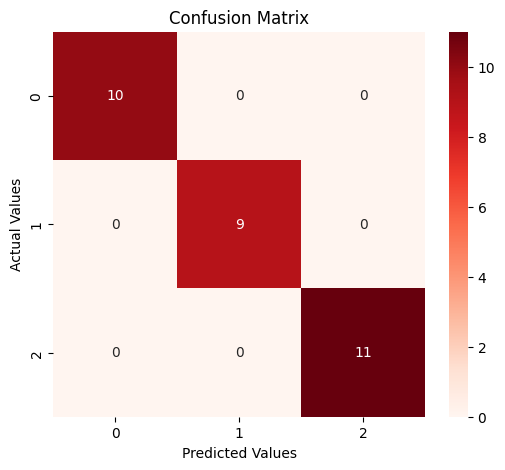

In [26]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted Values')

plt.ylabel('Actual Values')

plt.show()

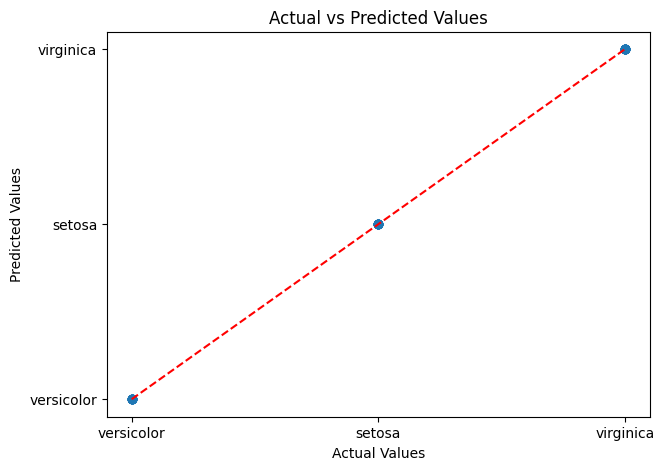

In [27]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

# Perfect Prediction Line
plt.plot(
    [0, 2],
    [0, 2],
    'r--'
)

plt.xlabel('Actual Values')

plt.ylabel('Predicted Values')

plt.title('Actual vs Predicted Values')

plt.show()

In [29]:
# ==========================================
# SAMPLE TEST INPUT
# ==========================================

sample_input = pd.DataFrame([[
    5.1,   # sepal length
    3.5,   # sepal width
    1.4,   # petal length
    0.2    # petal width
]], columns=X.columns)

# Predict
prediction = model.predict(sample_input)

print("Predicted Class:", prediction[0])

# Optional Flower Name Mapping
species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

print(
    "Predicted Species:",
    prediction[0]
)

Predicted Class: setosa
Predicted Species: setosa
